In [25]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from data_tools import process_data as processed
from data_tools.combine_data import CreateTrainingandTestData
from data_tools import process_dates
from data_tools import handle_datetime
from data_tools import clean_data as clean

combine = CreateTrainingandTestData()
# Change as needed
sensor_id = "TerraBella"
datatype = "o3"
year = "2025"

training_dates = process_dates.training(sensor_id, year)
testing_dates= process_dates.testing(sensor_id, year)

# Define files that hold necessary raw data
reference_file_1 = rf"../reference_files/OZONE_PICKDATA_2025-7-29-Fresno.csv"
reference_file_2 = rf"../reference_files/AQLite-2025-11-06.csv"
sensor_file = rf"../reference_files/2025rawdata/{sensor_id}.csv"
precal_reference = handle_datetime.utc_to_CA(processed.ref_data(reference_file_1))
postcal_reference = processed.standard_data(reference_file_2)
postcal_reference = postcal_reference.resample('h').mean()
postcal_reference.index = postcal_reference.index.map(lambda ts: ts.replace(minute=30, second=0, microsecond=0))
postcal_reference = handle_datetime.utc_to_CA(postcal_reference)
voz_data = handle_datetime.utc_to_CA(processed.raw_voz_data(sensor_file))

print(postcal_reference)

when = {
    "precal_start": training_dates[0],
    "precal_end": training_dates[1],
    "postcal_start": training_dates[2],
    "postcal_end": training_dates[3],
    "trial1_start": testing_dates[0],
    "trial1_end": testing_dates[1],
    "trial2_start": testing_dates[2],
    "trial2_end": testing_dates[3]
}

combine.set_calibration_parameters(datatype,sensor_id,voz_data)
training_data,all_data = combine.get_combined_data(training_dates,testing_dates,precal_reference,postcal_reference)
training_data, all_data = map(lambda df: clean.eliminate_waste_data_o3(df), [training_data, all_data])

                     reference
date_time                     
2025-10-21 14:30:00  70.500000
2025-10-21 15:30:00  69.608333
2025-10-21 16:30:00  69.800000
2025-10-21 17:30:00  66.327273
2025-10-21 18:30:00  54.225000
...                        ...
2025-11-06 11:30:00  36.325000
2025-11-06 12:30:00  38.525000
2025-11-06 13:30:00  38.850000
2025-11-06 14:30:00  39.208333
2025-11-06 15:30:00  39.566667

[386 rows x 1 columns]


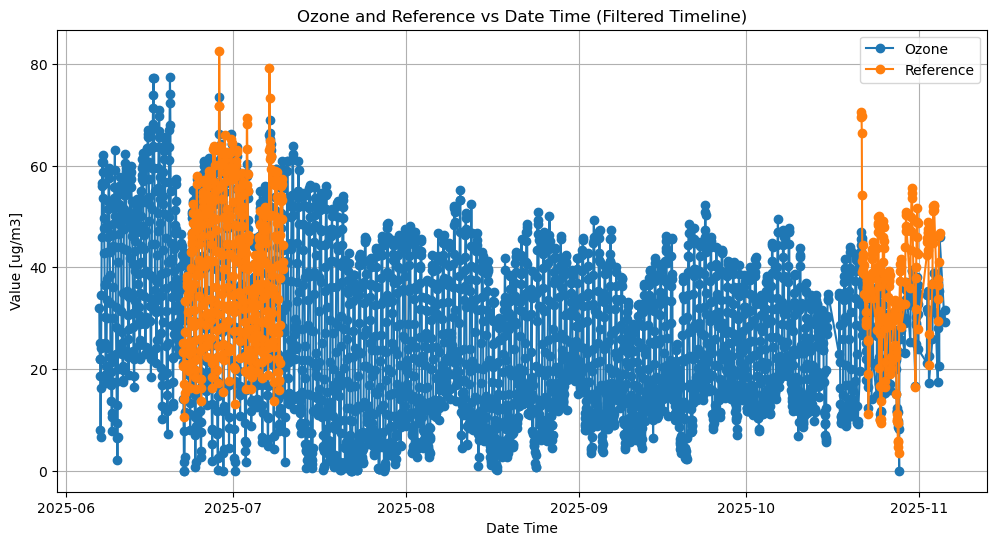

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the start and end dates for the desired timeline
start_date_filter = pd.to_datetime(f"{year}-06-07")
end_date_filter = pd.to_datetime(f"{year}-11-21")

# Apply the date range filter to the merged data
filtered_data = all_data[(all_data.index >= start_date_filter) & (all_data.index <= end_date_filter)]

# Line plot for 'o3' and 'reference' columns against 'date_time' within the specified timeline
plt.figure(figsize=(12, 6))

# Plot 'o3' column
plt.plot(filtered_data.index, filtered_data["o3"], label='Ozone', marker='o')

# Plot 'reference' column
plt.plot(filtered_data.index, filtered_data['reference'], label='Reference', marker='o')

# Customize the plot
plt.title('Ozone and Reference vs Date Time (Filtered Timeline)')
plt.xlabel('Date Time')
plt.ylabel('Value [ug/m3]')
plt.legend()
plt.grid(True)
plt.show()


In [27]:
from data_tools import elastic_net
#elasticnet regression with 2 variables

variables = ["o3","temp_C","rh"]
threevar_output = rf"../reference_files/2025rawdata/ozone_calibration_variables/{sensor_id}3Vars.csv"
new_column = "o3_calibrated_3var"

all_data = all_data.dropna(subset=variables)
training_data = training_data.dropna(subset=variables + ['reference'])
try:
    calibration_model = elastic_net.calibrate(training_data, variables, threevar_output)
    calibrated_data = elastic_net.apply_calibration(calibration_model,all_data,variables,new_column)
    print("Calibrated data:", calibrated_data[new_column])
except ValueError as e:
    print("Error:", e)



Range '0+' | Coefficients: [0.62163313 0.64345664 0.04559234] | Intercept: -1.160462129543781
Applied calibration models; results stored in 'o3_calibrated_3var'
Calibrated data: date_time
2025-06-02 16:30:00    62.546095
2025-06-02 17:30:00    61.941728
2025-06-02 18:30:00    61.176574
2025-06-02 19:30:00    59.911465
2025-06-02 20:30:00    54.973143
                         ...    
2025-11-04 14:30:00    32.332404
2025-11-04 15:30:00    40.216613
2025-11-04 16:30:00    44.419338
2025-11-05 13:30:00    32.904561
2025-11-05 14:30:00    33.868765
Name: o3_calibrated_3var, Length: 3485, dtype: float64


In [28]:
calibrated_file = rf"../reference_files/{year}OzoneDataCalibrated/{sensor_id}_calibrated.csv"
calibrated_data.to_csv(calibrated_file, index=True)

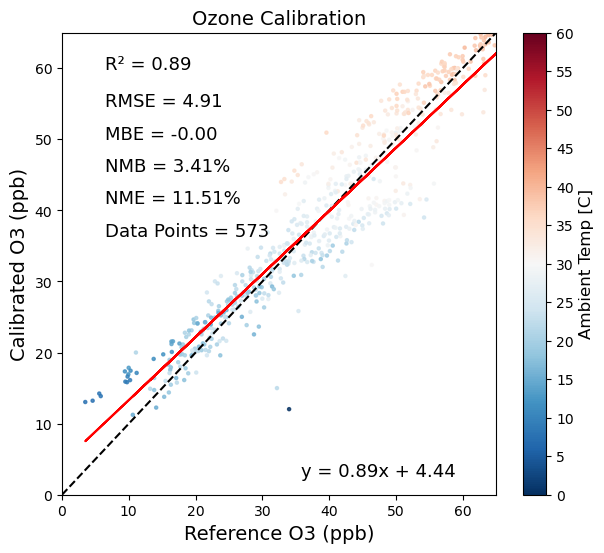

In [29]:
from data_tools.plot_against_reference import PlotOzone
po = PlotOzone()

training_data = combine.subsection(calibrated_data,training_dates)
testing_data = combine.subsection(calibrated_data,testing_dates)
# Base columns to always drop NAs for
training_data = training_data.dropna(subset=['reference'])
testing_data = testing_data.dropna(subset=['reference'])


po.plot(training_data,sensor_id,"Training")
# po.plot(all_data,sensor_id,"All")
# po.plot(testing_data,sensor_id,"Testing")

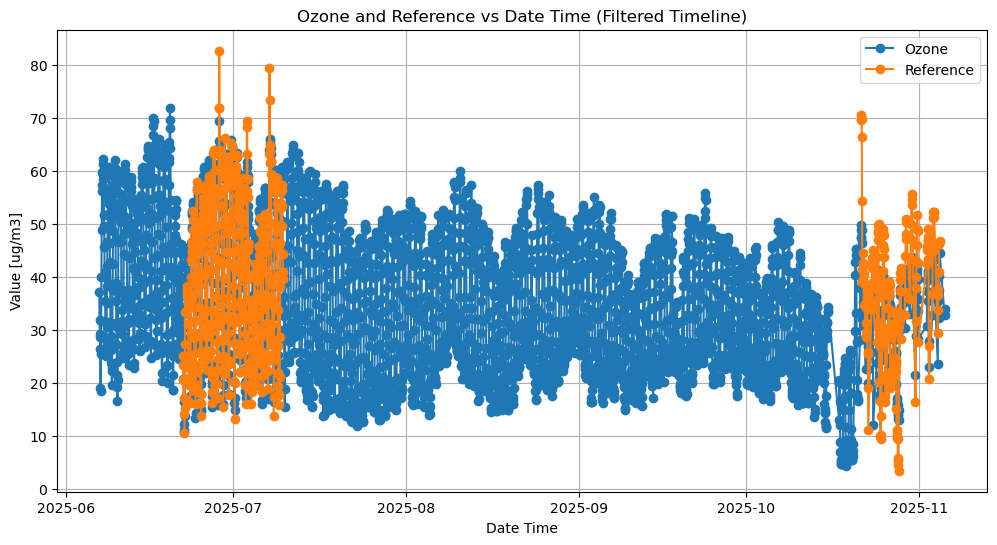

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the start and end dates for the desired timeline
start_date_filter = pd.to_datetime(f"{year}-06-07")
end_date_filter = pd.to_datetime(f"{year}-11-21")

# Apply the date range filter to the merged data
filtered_data = calibrated_data[(calibrated_data.index >= start_date_filter) & (calibrated_data.index <= end_date_filter)]

# Line plot for 'o3' and 'reference' columns against 'date_time' within the specified timeline
plt.figure(figsize=(12, 6))

# Plot 'o3' column
plt.plot(filtered_data.index, filtered_data["o3_calibrated_3var"], label='Ozone', marker='o')

# Plot 'reference' column
plt.plot(filtered_data.index, filtered_data['reference'], label='Reference', marker='o')

# Customize the plot
plt.title('Ozone and Reference vs Date Time (Filtered Timeline)')
plt.xlabel('Date Time')
plt.ylabel('Value [ug/m3]')
plt.legend()
plt.grid(True)
plt.show()
